# Boom model training

Same pipeline as [`train.py`](train.py), split into cells. Run top to bottom. Working directory should be the repo root.

In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import lightgbm as lgb
import shap
from scipy.special import expit, logit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import f1_score, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

### Feature helpers

These replace the local `features.py` import so the notebook is self-contained.

In [4]:
# Compute log(raw physical quantity), then z-score those log columns.
_LOG_SOURCES = {
    "pi_strength": "log_pi_strength",
    "coupling": "log_coupling",
    "porosity": "log_porosity",
    "shape_factor": "log_shape",
    "pi_threshold_fines": "log_pi_threshold_fines",
    "pi_threshold_oversize": "log_pi_threshold_oversize",
    "energy": "log_energy",
    "strength": "log_strength",
    "gravity": "log_gravity",
    "atmosphere": "log_atmosphere",
}
_EPS = 1e-6


def build_geometry(df: pd.DataFrame) -> pd.DataFrame:
    """Physics features before statistical scaling."""
    X = df.copy()
    X["L_char"] = (X["energy"] / (X["atmosphere"] * X["gravity"])) ** 0.25
    X["pi_strength"] = X["strength"] / (X["atmosphere"] * X["gravity"] * X["L_char"])

    X["sin_angle"] = np.sin(X["angle_rad"])
    X["cos_angle"] = np.cos(X["angle_rad"])

    X["D_fines"] = 40.0
    X["D_oversize"] = 120.0
    X["pi_threshold_fines"] = X["D_fines"] / X["L_char"]
    X["pi_threshold_oversize"] = X["D_oversize"] / X["L_char"]
    return X


class ZLogFeatureTransforms:
    """Fit StandardScaler on log-features; reuse it for validation/test."""

    def __init__(self):
        self._scalers: dict[str, StandardScaler] = {}

    def _raw_logs(self, geom: pd.DataFrame) -> pd.DataFrame:
        logs = pd.DataFrame(index=geom.index)
        for source, log_col in _LOG_SOURCES.items():
            logs[log_col] = np.log(geom[source].clip(lower=_EPS))
        return logs

    def fit(self, geom: pd.DataFrame) -> "ZLogFeatureTransforms":
        logs = self._raw_logs(geom)
        for log_col in logs:
            self._scalers[log_col] = StandardScaler().fit(logs[[log_col]].to_numpy())
        return self

    def transform(self, geom: pd.DataFrame) -> pd.DataFrame:
        X = geom.copy()
        logs = self._raw_logs(geom)
        for log_col in logs:
            raw_log = logs[[log_col]].to_numpy()
            X[f"{log_col}_raw"] = raw_log.ravel()
            X[log_col] = self._scalers[log_col].transform(raw_log).ravel()
        return X


def build_features(df: pd.DataFrame, z_log: ZLogFeatureTransforms) -> pd.DataFrame:
    """Raw scenario table + fitted train scaler -> full feature matrix."""
    return z_log.transform(build_geometry(df))


def transform_targets(y: pd.DataFrame, L_char: pd.Series) -> pd.DataFrame:
    y_t = pd.DataFrame(index=y.index)
    for col in ["P80", "R95", "R50_fines", "R50_oversize"]:
        y_t[f"log_pi_{col}"] = np.log(y[col] / L_char)

    y_t["logit_fines_frac"] = logit(y["fines_frac"].clip(_EPS, 1 - _EPS))
    y_t["logit_oversize_frac"] = logit(y["oversize_frac"].clip(_EPS, 1 - _EPS))
    return y_t


def invert_targets(y_pred: pd.DataFrame, L_char: pd.Series) -> pd.DataFrame:
    y_out = pd.DataFrame(index=y_pred.index)
    for col in ["P80", "R95", "R50_fines", "R50_oversize"]:
        y_out[col] = np.exp(y_pred[f"log_pi_{col}"]) * L_char
    y_out["fines_frac"] = expit(y_pred["logit_fines_frac"])
    y_out["oversize_frac"] = expit(y_pred["logit_oversize_frac"])
    return y_out

### Model helpers

These replace the local `models.py` import so the notebook is self-contained.

In [5]:
# Base features shared by all models
LENGTH_LINEAR_FEATURES = [
    "log_pi_strength",
    "log_coupling",
    "log_porosity",
    "log_shape",
    "sin_angle",
    "cos_angle",
]

BASE_LGB_FEATURES = LENGTH_LINEAR_FEATURES + [
    "log_energy",
    "log_strength",
    "log_gravity",
    "log_atmosphere",
]

# Target-specific feature lists
FINES_LINEAR_FEATURES = LENGTH_LINEAR_FEATURES + ["log_pi_threshold_fines"]
FINES_LGB_FEATURES = BASE_LGB_FEATURES + ["log_pi_threshold_fines"]

OVERSIZE_LINEAR_FEATURES = LENGTH_LINEAR_FEATURES + ["log_pi_threshold_oversize"]
OVERSIZE_LGB_FEATURES = BASE_LGB_FEATURES + ["log_pi_threshold_oversize"]

LENGTH_TARGETS = ["log_pi_P80", "log_pi_R95", "log_pi_R50_fines", "log_pi_R50_oversize"]
FRACTION_TARGETS = ["logit_fines_frac", "logit_oversize_frac"]
ALL_TARGETS = LENGTH_TARGETS + FRACTION_TARGETS


class HybridPhysicsModel:
    def __init__(self, linear_features, lgb_features, lgb_params=None):
        self.linear_features = linear_features
        self.lgb_features = lgb_features
        self.lgb_params = lgb_params or {
            "n_estimators": 500,
            "learning_rate": 0.05,
            "num_leaves": 31,
            "min_child_samples": 10,
            "reg_alpha": 0.1,
            "reg_lambda": 0.1,
            "verbose": -1,
        }
        self.baseline = None
        self.residual = None
        self.best_iteration_ = None

    def fit(self, X, y, eval_set=None, eval_names=None, eval_metric="l2", callbacks=None):
        self.baseline = LinearRegression().fit(X[self.linear_features], y)
        residuals = y - self.baseline.predict(X[self.linear_features])
        residual_eval_set = None
        if eval_set is not None:
            residual_eval_set = []
            for X_eval, y_eval in eval_set:
                residual_eval_set.append((
                    X_eval[self.lgb_features],
                    y_eval - self.baseline.predict(X_eval[self.linear_features]),
                ))

        self.residual = lgb.LGBMRegressor(**self.lgb_params).fit(
            X[self.lgb_features],
            residuals,
            eval_set=residual_eval_set,
            eval_names=eval_names,
            eval_metric=eval_metric,
            callbacks=callbacks,
        )
        self.best_iteration_ = getattr(self.residual, "best_iteration_", None)
        return self

    def predict(self, X):
        num_iteration = self.best_iteration_ if self.best_iteration_ else None
        return (
            self.baseline.predict(X[self.linear_features])
            + self.residual.predict(X[self.lgb_features], num_iteration=num_iteration)
        )

    def baseline_coefficients(self):
        return pd.Series(self.baseline.coef_, index=self.linear_features)


def make_model(target: str) -> HybridPhysicsModel:
    if target == "logit_fines_frac":
        return HybridPhysicsModel(linear_features=FINES_LINEAR_FEATURES, lgb_features=FINES_LGB_FEATURES)
    if target == "logit_oversize_frac":
        return HybridPhysicsModel(linear_features=OVERSIZE_LINEAR_FEATURES, lgb_features=OVERSIZE_LGB_FEATURES)
    return HybridPhysicsModel(linear_features=LENGTH_LINEAR_FEATURES, lgb_features=BASE_LGB_FEATURES)

### Configuration

In [6]:
data_dir = "forward_prediction"
n_splits = 5
seed = 42

### Load raw training data

In [7]:
X_raw = pd.read_csv(f"{data_dir}/train.csv").reset_index(drop=True)
y_raw = pd.read_csv(f"{data_dir}/train_labels.csv").reset_index(drop=True)
if len(X_raw) != len(y_raw):
    raise ValueError(
        f"{data_dir}/train.csv ({len(X_raw)} rows) and "
        f"{data_dir}/train_labels.csv ({len(y_raw)} rows) must align"
    )

### Feature engineering and transformed targets

In [8]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

geom = build_geometry(X_raw)
z_log = ZLogFeatureTransforms().fit(geom)
X = build_features(X_raw, z_log)
y = transform_targets(y_raw, X["L_char"])

X

,porosity,atmosphere,gravity,coupling,strength,shape_factor,energy,angle_rad,L_char,pi_strength,sin_angle,cos_angle,D_fines,D_oversize,pi_threshold_fines,pi_threshold_oversize,log_pi_strength_raw,log_pi_strength,log_coupling_raw,log_coupling,log_porosity_raw,log_porosity,log_shape_raw,log_shape,log_pi_threshold_fines_raw,log_pi_threshold_fines,log_pi_threshold_oversize_raw,log_pi_threshold_oversize,log_energy_raw,log_energy,log_strength_raw,log_strength,log_gravity_raw,log_gravity,log_atmosphere_raw,log_atmosphere
0,0.337215,0.781263,3.71,0.861258,1.305809,0.784028,3.826405,0.818303,1.071902,0.420294,0.729987,0.683461,40.0,120.0,37.316860,111.950580,-0.866800,-1.240799,-0.149361,0.479957,-1.087034,0.973482,-0.243311,-1.630690,3.619445,0.840719,4.718058,0.840719,1.341926,1.066967,0.266823,-1.513414,1.311032,-0.043754,-0.246843,1.262984
1,0.058029,0.136205,1.62,0.561245,3.494501,0.922737,2.828754,1.193036,1.892220,8.369596,0.929493,0.368839,40.0,120.0,21.139196,63.417587,2.124606,1.304011,-0.577597,-0.813921,-2.846804,-0.315970,-0.080411,-0.417376,3.051129,-1.234807,4.149741,-1.234807,1.039836,-0.962182,1.251190,0.932442,0.482426,-1.177343,-1.993592,-0.721571
2,0.315632,0.774704,3.71,0.948860,1.366386,0.954922,3.068907,0.605872,1.016526,0.467676,0.569479,0.822006,40.0,120.0,39.349703,118.049108,-0.759979,-1.149925,-0.052494,0.772632,-1.153180,0.925015,-0.046125,-0.162012,3.672488,1.034436,4.771101,1.034436,1.121321,-0.414843,0.312169,-1.400741,1.311032,-0.043754,-0.255275,1.253405
3,0.033062,0.144204,1.62,0.713705,3.599419,0.932911,2.700574,1.073708,1.843915,8.356010,0.878975,0.476868,40.0,120.0,21.692975,65.078926,2.122981,1.302629,-0.337286,-0.087841,-3.409364,-0.728180,-0.069446,-0.335707,3.076988,-1.140367,4.175601,-1.140367,0.993464,-1.273666,1.280772,1.005944,0.482426,-1.177343,-1.936526,-0.656736
4,0.278207,0.414620,9.81,1.237205,1.996742,1.260855,3.484022,0.863568,0.962034,0.510284,0.760166,0.649729,40.0,120.0,41.578583,124.735748,-0.672788,-1.075751,0.212854,1.574360,-1.279390,0.832536,0.231790,1.907955,3.727585,1.235653,4.826197,1.235653,1.248187,0.437321,0.691517,-0.458178,2.283402,1.286514,-0.880392,0.543183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,0.063837,0.186159,3.71,0.690423,3.137082,0.901161,2.743598,1.286277,1.411776,3.217382,0.959797,0.280696,40.0,120.0,28.333111,84.999332,1.168568,0.490703,-0.370451,-0.188047,-2.751417,-0.246076,-0.104071,-0.593605,3.344031,-0.165110,4.442643,-0.165110,1.009270,-1.167497,1.143293,0.664350,1.311032,-0.043754,-1.681155,-0.366598
2926,0.299258,0.425989,9.81,0.491482,1.209891,0.868630,3.629967,0.638878,0.965403,0.299896,0.596295,0.802765,40.0,120.0,41.433454,124.300361,-1.204320,-1.527929,-0.710330,-1.214961,-1.206450,0.885981,-0.140838,-0.867449,3.724089,1.222883,4.822701,1.222883,1.289224,0.712964,0.190531,-1.702976,2.283402,1.286514,-0.853342,0.573915
2927,0.264179,0.446155,1.62,0.650748,1.377509,0.979404,3.517622,0.705479,1.485293,1.283163,0.648399,0.761301,40.0,120.0,26.930709,80.792126,0.249328,-0.291300,-0.429633,-0.366860,-1.331129,0.794624,-0.020812,0.026529,3.293267,-0.350503,4.391880,-0.350503,1.257785,0.501792,0.320277,-1.380596,0.482426,-1.177343,-0.807090,0.626464
2928,0.078473,0.143900,3.71,0.719509,3.546015,0.970048,2.995128,1.218927,1.539024,4.315796,0.938730,0.344653,40.0,120.0,25.990506,77.971519,1.462282,0.740567,-0.329186,-0.063370,-2.544997,-0.094824,-0.030410,-0.044960,3.257731,-0.480283,4.356344,-0.480283,1.096987,-0.578297,1.265824,0.968803,1.311032,-0.043754,-1.938637,-0.659135


In [9]:
y

,log_pi_P80,log_pi_R95,log_pi_R50_fines,log_pi_R50_oversize,logit_fines_frac,logit_oversize_frac
0,4.274012,5.223563,5.098364,4.264397,-1.484636,-4.077251
1,4.957174,4.839836,5.465161,4.317330,-7.381744,2.398781
2,4.628682,5.246229,5.226870,4.417229,-2.581431,-2.260607
3,4.939588,5.055538,5.602717,4.523122,-6.880776,1.993589
4,4.754676,4.584437,4.619736,3.798239,-2.777066,-1.847503
...,...,...,...,...,...,...
2925,5.008049,4.407734,4.888262,3.863199,-6.405178,1.402690
2926,4.691964,4.216898,4.256279,3.469221,-2.882806,-2.195031
2927,4.217031,6.055379,6.072053,5.225958,-2.741146,-2.531467
2928,4.925463,4.595312,5.080243,4.062388,-6.427631,1.476609


### Cross-validation setup

F1 uses above/below **training-fold median** splits (regression targets binarized per fold).

In [10]:
kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
physical_cols = ["P80", "R95", "R50_fines", "R50_oversize", "fines_frac", "oversize_frac"]
physical_scores = {c: [] for c in physical_cols}
physical_mape = {c: [] for c in physical_cols}
physical_r2 = {c: [] for c in physical_cols}
physical_f1 = {c: [] for c in physical_cols}
convergence_history = {}
shap_history = {}
best_iterations = {t: [] for t in ALL_TARGETS}
early_stopping_rounds = 30
plot_shap_dependence = True

### CV loop: train per target, validate RMSE/F1, log convergence, and early stop

Each LightGBM residual model logs train/validation residual `l2` every 10 boosting rounds. Early stopping watches validation residual `l2`; best iterations are stored in `best_iterations[target]`.

In [11]:
for fold, (tr, va) in enumerate(kf.split(X)):
    X_tr, X_va = X.iloc[tr], X.iloc[va]
    y_tr, y_va = y.iloc[tr], y.iloc[va]
    y_tr_phys = y_raw.iloc[tr].reset_index(drop=True)

    preds_transformed = pd.DataFrame(index=X_va.index)
    for target in ALL_TARGETS:
        print(f"\n=== Fold {fold} / {target} convergence ===")
        model = make_model(target)

        # Fit the linear baseline first, then early-stop LightGBM on validation residual l2.
        model.baseline = LinearRegression().fit(X_tr[model.linear_features], y_tr[target])
        train_residuals = y_tr[target] - model.baseline.predict(X_tr[model.linear_features])
        valid_residuals = y_va[target] - model.baseline.predict(X_va[model.linear_features])

        evals_result = {}
        model.residual = lgb.LGBMRegressor(**model.lgb_params).fit(
            X_tr[model.lgb_features],
            train_residuals,
            eval_set=[
                (X_va[model.lgb_features], valid_residuals),
                (X_tr[model.lgb_features], train_residuals),
            ],
            eval_names=["valid_residual", "train_residual"],
            eval_metric="l2",
            callbacks=[
                lgb.record_evaluation(evals_result),
                lgb.log_evaluation(period=10),
                lgb.early_stopping(stopping_rounds=early_stopping_rounds, first_metric_only=True),
            ],
        )
        model.best_iteration_ = model.residual.best_iteration_
        convergence_history[(fold, target)] = evals_result

        valid_l2 = evals_result["valid_residual"]["l2"]
        best_iter = model.best_iteration_ or (int(np.argmin(valid_l2)) + 1)
        best_iterations[target].append(best_iter)
        print(
            f"Fold {fold} / {target}: valid_l2 start={valid_l2[0]:.6g}, "
            f"end={valid_l2[-1]:.6g}, best={min(valid_l2):.6g} at iter {best_iter}"
        )
        preds_transformed[target] = model.predict(X_va)

        # SHAP explains the LightGBM residual correction, not the linear baseline.
        explainer = shap.TreeExplainer(model.residual)
        shap_values = explainer.shap_values(X_va[model.lgb_features])
        shap_history[(fold, target)] = {
            "values": shap_values,
            "features": X_va[model.lgb_features].copy(),
            "feature_names": model.lgb_features,
        }

        if plot_shap_dependence:
            for feature_to_plot in model.lgb_features:
                shap.dependence_plot(
                    feature_to_plot,
                    shap_values,
                    X_va[model.lgb_features],
                    interaction_index="auto",
                    show=False,
                )
                plt.title(f"SHAP Dependence Plot: {feature_to_plot} (Fold {fold}, Target: {target})")
                plt.tight_layout()
                plt.show()

    preds_physical = invert_targets(preds_transformed, X_va["L_char"]).reset_index(drop=True)
    y_va_phys = y_raw.iloc[va].reset_index(drop=True)
    for col in physical_cols:
        y_true = y_va_phys[col].to_numpy()
        y_pred = preds_physical[col].to_numpy()
        physical_scores[col].append(np.sqrt(mean_squared_error(y_true, y_pred)))
        physical_mape[col].append(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
        physical_r2[col].append(r2_score(y_true, y_pred))

        thr = np.median(y_tr_phys[col])
        y_bin = (y_true > thr).astype(int)
        p_bin = (y_pred > thr).astype(int)
        physical_f1[col].append(f1_score(y_bin, p_bin, zero_division=0))
    print(
        f"Fold {fold} RMSE: " + ", ".join(f"{c}={physical_scores[c][-1]:.4f}" for c in physical_cols)
    )
    print(
        f"Fold {fold} MAPE: " + ", ".join(f"{c}={physical_mape[c][-1]:.2f}%" for c in physical_cols)
    )
    print(
        f"Fold {fold} R^2:  " + ", ".join(f"{c}={physical_r2[c][-1]:.4f}" for c in physical_cols)
    )
    print(
        f"Fold {fold} F1:   " + ", ".join(f"{c}={physical_f1[c][-1]:.4f}" for c in physical_cols)
    )


=== Fold 0 / log_pi_P80 convergence ===
Training until validation scores don't improve for 30 rounds
[10]	valid_residual's l2: 0.0279504	train_residual's l2: 0.0265404
[20]	valid_residual's l2: 0.0168274	train_residual's l2: 0.0147647
[30]	valid_residual's l2: 0.0112392	train_residual's l2: 0.0090262
[40]	valid_residual's l2: 0.00841981	train_residual's l2: 0.00607846
[50]	valid_residual's l2: 0.00686586	train_residual's l2: 0.00445233
[60]	valid_residual's l2: 0.0058899	train_residual's l2: 0.00347812
[70]	valid_residual's l2: 0.00529196	train_residual's l2: 0.00285042
[80]	valid_residual's l2: 0.00491684	train_residual's l2: 0.00244147
[90]	valid_residual's l2: 0.00466486	train_residual's l2: 0.00214948
[100]	valid_residual's l2: 0.0044864	train_residual's l2: 0.00194504
[110]	valid_residual's l2: 0.00436644	train_residual's l2: 0.00178856
[120]	valid_residual's l2: 0.00427605	train_residual's l2: 0.00166231
[130]	valid_residual's l2: 0.0042311	train_residual's l2: 0.00155913
[140]	

### Optional SHAP Summary Plot

Use this to inspect overall residual-model feature importance for one fold and target after the CV loop has run.

In [ ]:
summary_fold = 0
summary_target = ALL_TARGETS[0]
entry = shap_history.get((summary_fold, summary_target))
if entry is None:
    print(f"No SHAP values found for fold={summary_fold}, target={summary_target}. Run the CV loop first.")
else:
    shap.summary_plot(entry["values"], entry["features"], show=False)
    plt.title(f"SHAP Summary Plot (Fold {summary_fold}, Target: {summary_target})")
    plt.tight_layout()
    plt.show()

### LightGBM convergence plots

These plots show residual `l2` by boosting iteration. If validation `l2` keeps decreasing, the model is still learning; if it flattens, more trees likely do little; if it rises while train keeps falling, that target/fold is overfitting.

Saved LightGBM train/valid convergence plot to lgbm_convergence.png


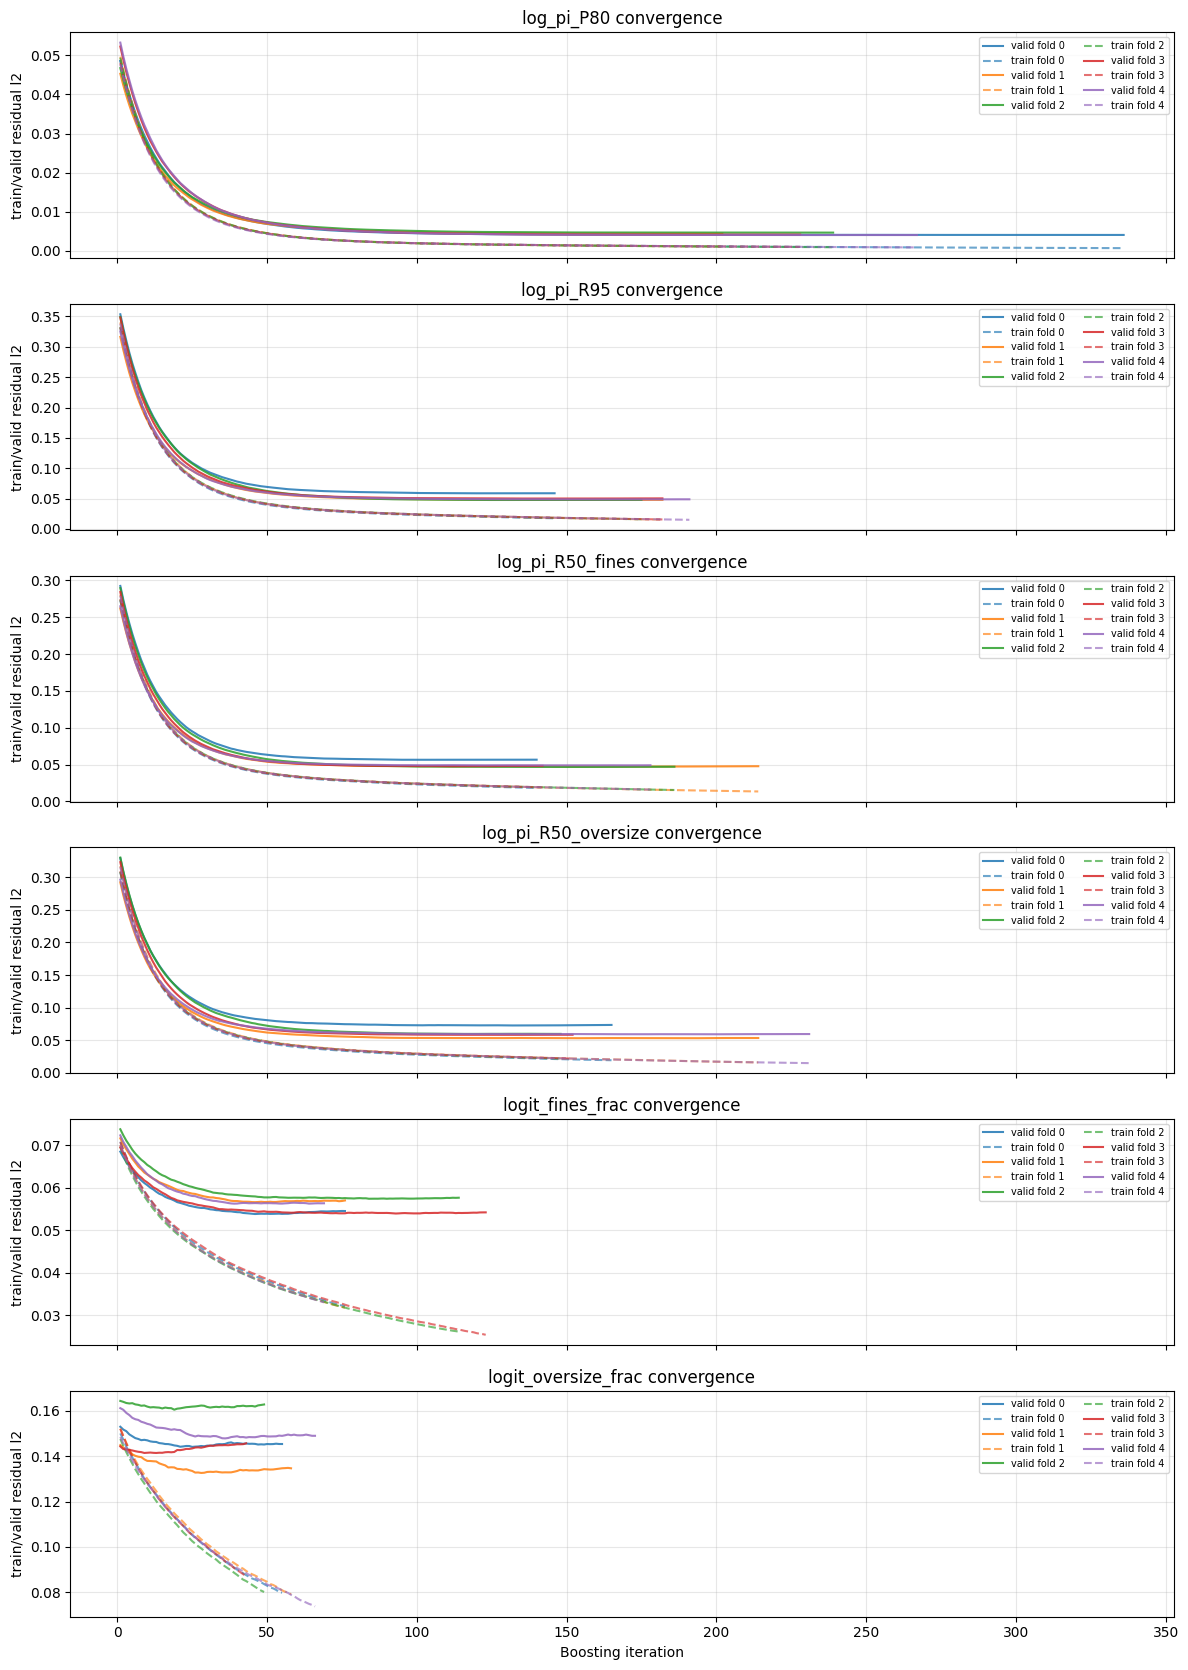

In [12]:
fig, axes = plt.subplots(len(ALL_TARGETS), 1, figsize=(12, 2.8 * len(ALL_TARGETS)), sharex=True)
for ax, target in zip(axes, ALL_TARGETS):
    train_vals_all = []
    valid_vals_all = []
    for fold in range(n_splits):
        hist = convergence_history.get((fold, target))
        if hist is None:
            continue
        train_vals_all.extend(hist["train_residual"]["l2"])
        valid_vals_all.extend(hist["valid_residual"]["l2"])

    if not train_vals_all or not valid_vals_all:
        ax.set_title(f"{target} (no convergence history)")
        continue

    train_max = max(train_vals_all)
    valid_max = max(valid_vals_all)
    scale_ratio = max(train_max, valid_max) / max(min(train_max, valid_max), 1e-12)
    use_twin_axis = scale_ratio > 5
    train_ax = ax.twinx() if use_twin_axis else ax

    for fold in range(n_splits):
        hist = convergence_history.get((fold, target))
        if hist is None:
            continue
        train_l2 = hist["train_residual"]["l2"]
        valid_l2 = hist["valid_residual"]["l2"]
        iters = np.arange(1, len(valid_l2) + 1)
        color = f"C{fold}"
        ax.plot(iters, valid_l2, color=color, linestyle="-", alpha=0.85, label=f"valid fold {fold}")
        train_ax.plot(iters, train_l2, color=color, linestyle="--", alpha=0.65, label=f"train fold {fold}")

    ax.set_title(f"{target} convergence")
    ax.set_ylabel("valid residual l2")
    train_ax.set_ylabel("train residual l2" if use_twin_axis else "train/valid residual l2")
    ax.grid(True, alpha=0.3)

    valid_handles, valid_labels = ax.get_legend_handles_labels()
    train_handles, train_labels = train_ax.get_legend_handles_labels()
    if use_twin_axis:
        train_ax.legend(
            valid_handles + train_handles,
            valid_labels + train_labels,
            loc="best",
            fontsize=7,
            ncol=2,
        )
    else:
        ax.legend(loc="best", fontsize=7, ncol=2)

axes[-1].set_xlabel("Boosting iteration")
plt.tight_layout()
plt.savefig("lgbm_convergence.png", dpi=150)
print("Saved LightGBM train/valid convergence plot to lgbm_convergence.png")
plt.show()

### Mean CV metrics (physical units)

In [29]:
print("\nMean CV RMSE (physical units):")
for c in physical_cols:
    print(f"  {c}: {np.mean(physical_scores[c]):.4f} ± {np.std(physical_scores[c]):.4f}")

print("\nMean CV MAPE (%):")
for c in physical_cols:
    print(f"  {c}: {np.mean(physical_mape[c]):.2f}% ± {np.std(physical_mape[c]):.2f}%")

print("\nMean CV R^2:")
for c in physical_cols:
    print(f"  {c}: {np.mean(physical_r2[c]):.4f} ± {np.std(physical_r2[c]):.4f}")

print("\nMean CV F1 (median split vs training fold, physical units):")
for c in physical_cols:
    print(f"  {c}: {np.mean(physical_f1[c]):.4f} ± {np.std(physical_f1[c]):.4f}")


Mean CV RMSE (physical units):
  P80: 11.6240 ± 0.3348
  R95: 72.4331 ± 2.4902
  R50_fines: 83.4913 ± 3.0768
  R50_oversize: 39.8462 ± 1.3292
  fines_frac: 0.0142 ± 0.0013
  oversize_frac: 0.0365 ± 0.0011

Mean CV F1 (median split vs training fold, physical units):
  P80: 0.9678 ± 0.0096
  R95: 0.9651 ± 0.0046
  R50_fines: 0.8864 ± 0.0153
  R50_oversize: 0.9310 ± 0.0074
  fines_frac: 0.9755 ± 0.0025
  oversize_frac: 0.9720 ± 0.0052


### CV metric plot


Saved CV metric plot to cv_metrics.png


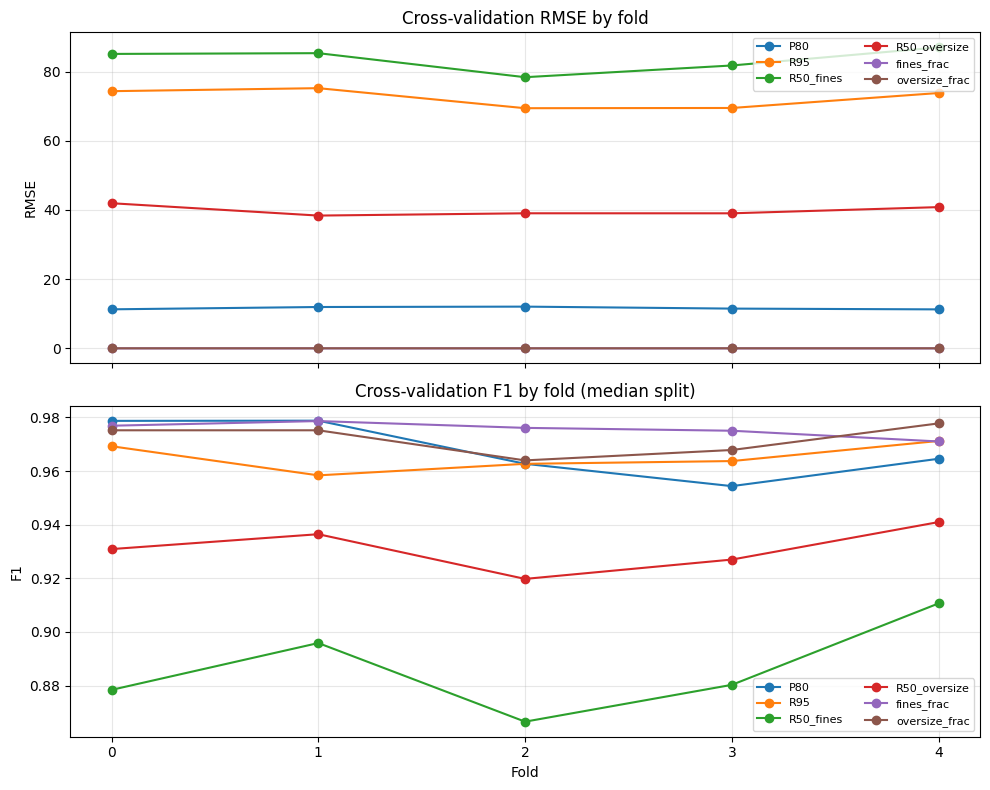

In [30]:
rmse_array = np.column_stack([physical_scores[c] for c in physical_cols])
mape_array = np.column_stack([physical_mape[c] for c in physical_cols])
r2_array = np.column_stack([physical_r2[c] for c in physical_cols])
f1_array = np.column_stack([physical_f1[c] for c in physical_cols])

fold_idx = np.arange(n_splits)
fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)
ax_rmse, ax_mape, ax_r2, ax_f1 = axes
for j, col in enumerate(physical_cols):
    ax_rmse.plot(fold_idx, rmse_array[:, j], marker="o", label=col)
    ax_mape.plot(fold_idx, mape_array[:, j], marker="o", label=col)
    ax_r2.plot(fold_idx, r2_array[:, j], marker="o", label=col)
    ax_f1.plot(fold_idx, f1_array[:, j], marker="o", label=col)
ax_rmse.set_ylabel("RMSE")
ax_rmse.set_title("Cross-validation RMSE by fold")
ax_mape.set_ylabel("MAPE (%)")
ax_mape.set_title("Cross-validation MAPE by fold")
ax_r2.set_ylabel("R²")
ax_r2.set_title("Cross-validation R² by fold")
ax_f1.set_xlabel("Fold")
ax_f1.set_ylabel("F1")
ax_f1.set_title("Cross-validation F1 by fold (median split)")
for ax in axes:
    ax.legend(loc="best", ncol=2, fontsize=8)
    ax.grid(True, alpha=0.3)
ax_f1.set_xticks(fold_idx)
plt.tight_layout()
plt.savefig("cv_metrics.png", dpi=150)
print("\nSaved CV metric plot to cv_metrics.png")
plt.show()

### Stack per-fold RMSE and F1 for plotting

In [11]:
rmse_array = np.column_stack([physical_scores[c] for c in physical_cols])
mape_array = np.column_stack([physical_mape[c] for c in physical_cols])
r2_array = np.column_stack([physical_r2[c] for c in physical_cols])
f1_array = np.column_stack([physical_f1[c] for c in physical_cols])

### Best iterations from early stopping

Use the median best iteration across folds as the final `n_estimators` for each target.

In [31]:
final_n_estimators = {}
print("Best LightGBM iterations by target:")
for target in ALL_TARGETS:
    final_n_estimators[target] = int(np.median(best_iterations[target]))
    print(
        f"  {target}: folds={best_iterations[target]}, "
        f"median_for_final_fit={final_n_estimators[target]}"
    )

Best LightGBM iterations by target:
  log_pi_P80: folds=[306, 172, 209, 198, 237], median_for_final_fit=209
  log_pi_R95: folds=[116, 152, 145, 152, 161], median_for_final_fit=152
  log_pi_R50_fines: folds=[110, 184, 156, 112, 148], median_for_final_fit=148
  log_pi_R50_oversize: folds=[135, 184, 118, 122, 201], median_for_final_fit=135
  logit_fines_frac: folds=[46, 46, 84, 93, 39], median_for_final_fit=46
  logit_oversize_frac: folds=[25, 28, 19, 13, 36], median_for_final_fit=25


### Fit final models on full data

In [32]:
final_models = {}
for target in ALL_TARGETS:
    model = make_model(target)
    model.lgb_params = {**model.lgb_params, "n_estimators": final_n_estimators[target]}
    final_models[target] = model.fit(X, y[target])
    print(
        f"\n{target} final n_estimators={final_n_estimators[target]} "
        f"baseline coefficients:\n{final_models[target].baseline_coefficients()}"
    )


log_pi_P80 final n_estimators=209 baseline coefficients:
log_pi_strength   -0.203267
log_coupling      -0.136745
log_porosity      -0.079712
log_shape         -0.003383
sin_angle          0.035676
cos_angle         -1.055204
dtype: float64

log_pi_R95 final n_estimators=152 baseline coefficients:
log_pi_strength    0.743633
log_coupling       0.196882
log_porosity       0.272372
log_shape          0.022152
sin_angle         -0.246635
cos_angle          3.640711
dtype: float64

log_pi_R50_fines final n_estimators=148 baseline coefficients:
log_pi_strength    0.816058
log_coupling       0.107972
log_porosity       0.233346
log_shape          0.017681
sin_angle         -0.157242
cos_angle          3.194458
dtype: float64

log_pi_R50_oversize final n_estimators=135 baseline coefficients:
log_pi_strength    0.788187
log_coupling       0.127228
log_porosity       0.258551
log_shape          0.031797
sin_angle         -0.040997
cos_angle          3.556134
dtype: float64

logit_fines_frac fin

### Save trained models

In [33]:
joblib.dump(final_models, "models.joblib")

['models.joblib']